Saving STUDENT.csv to STUDENT (5).csv
STUDENT DATA


,NAME,PYTHON,CPP,JAVA
0,AKSHAYA.V.H,90,40,59
1,AKSHITHY.N,80,50,79
2,ANUTHRA.R,70,60,99
3,ASMI.E,60,70,49
4,ASWINI.A,90,80,89
5,ATHIRA.S.S,40,90,79
6,DHANYA.V.R,50,90,69
7,GOPIKA.M,60,80,59
8,MINU.S.J,70,70,69
9,NEENA.V,80,60,79



STUDENT PERFORMANCE REPORT


,NAME,PYTHON,CPP,JAVA,AVERAGE,GRADE,PASS/FAIL
0,AKSHAYA.V.H,90,40,59,63.000000,C,Pass
1,AKSHITHY.N,80,50,79,69.666667,C,Pass
2,ANUTHRA.R,70,60,99,76.333333,B,Pass
3,ASMI.E,60,70,49,59.666667,D,Pass
4,ASWINI.A,90,80,89,86.333333,A,Pass
5,ATHIRA.S.S,40,90,79,69.666667,C,Pass
6,DHANYA.V.R,50,90,69,69.666667,C,Pass
7,GOPIKA.M,60,80,59,66.333333,C,Pass
8,MINU.S.J,70,70,69,69.666667,C,Pass
9,NEENA.V,80,60,79,73.000000,B,Pass



SUBJECT-WISE PERFORMANCE
PYTHON    66.666667
CPP       62.916667
JAVA      76.500000
dtype: float64

Best Performing Subject : JAVA
Lowest Performing Subject : CPP


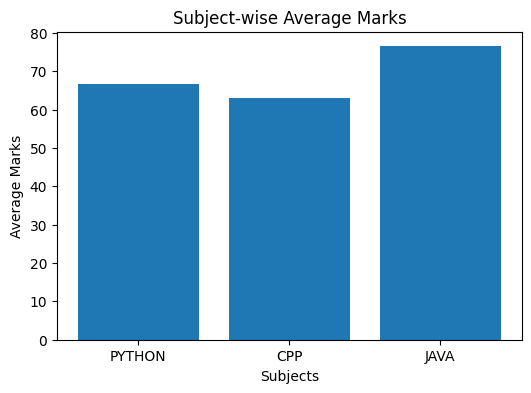

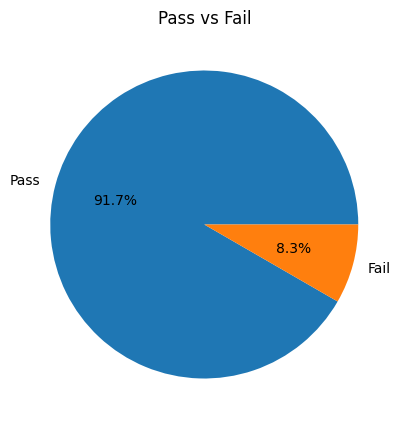

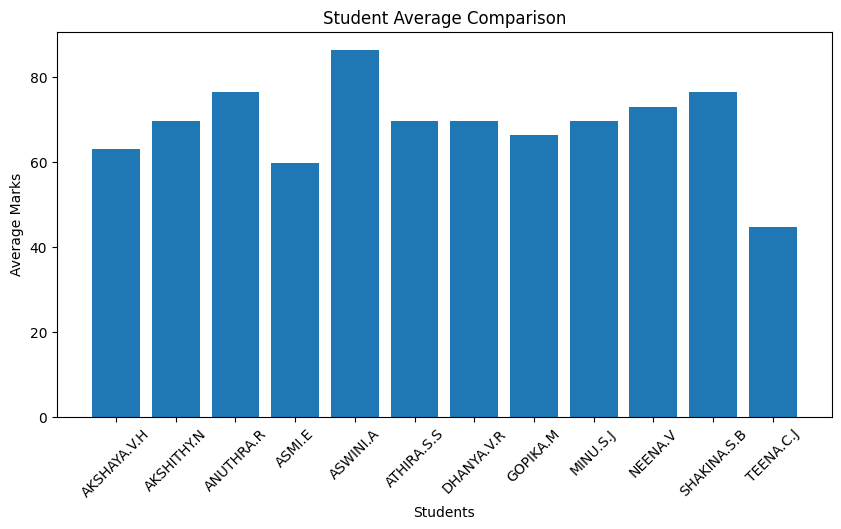

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Upload CSV file
uploaded = files.upload()

# Read CSV file
df = pd.read_csv(list(uploaded.keys())[0])

# Remove empty columns if present
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Display original data
print("STUDENT DATA")
display(df)

# Subject columns
subjects = ['PYTHON', 'CPP', 'JAVA']

# Calculate Average
df['AVERAGE'] = df[subjects].mean(axis=1)

# Calculate Grade
def grade(avg):
    if avg >= 90:
        return 'A+'
    elif avg >= 80:
        return 'A'
    elif avg >= 70:
        return 'B'
    elif avg >= 60:
        return 'C'
    elif avg >= 50:
        return 'D'
    else:
        return 'F'

df['GRADE'] = df['AVERAGE'].apply(grade)

# Calculate Pass/Fail
df['PASS/FAIL'] = df['AVERAGE'].apply(
    lambda x: 'Pass' if x >= 50 else 'Fail'
)

# Display result
print("\nSTUDENT PERFORMANCE REPORT")
display(df)
# Subject-wise Performance
subject_avg = df[subjects].mean()

print("\nSUBJECT-WISE PERFORMANCE")
print(subject_avg)

# Best and Lowest Subject
print("\nBest Performing Subject :", subject_avg.idxmax())
print("Lowest Performing Subject :", subject_avg.idxmin())
# Chart 1 : Subject-wise Average
# -----------------------------
plt.figure(figsize=(6,4))
plt.bar(subject_avg.index, subject_avg.values)
plt.title("Subject-wise Average Marks")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")
plt.show()

# -----------------------------
# Chart 2 : Pass vs Fail
# -----------------------------
status_count = df['PASS/FAIL'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(status_count,
        labels=status_count.index,
        autopct='%1.1f%%')
plt.title("Pass vs Fail")
plt.show()

# -----------------------------
# Chart 3 : Student Comparison
# -----------------------------
plt.figure(figsize=(10,5))
plt.bar(df['NAME'], df['AVERAGE'])
plt.title("Student Average Comparison")
plt.xlabel("Students")
plt.ylabel("Average Marks")
plt.xticks(rotation=45)
plt.show()
